# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [15]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

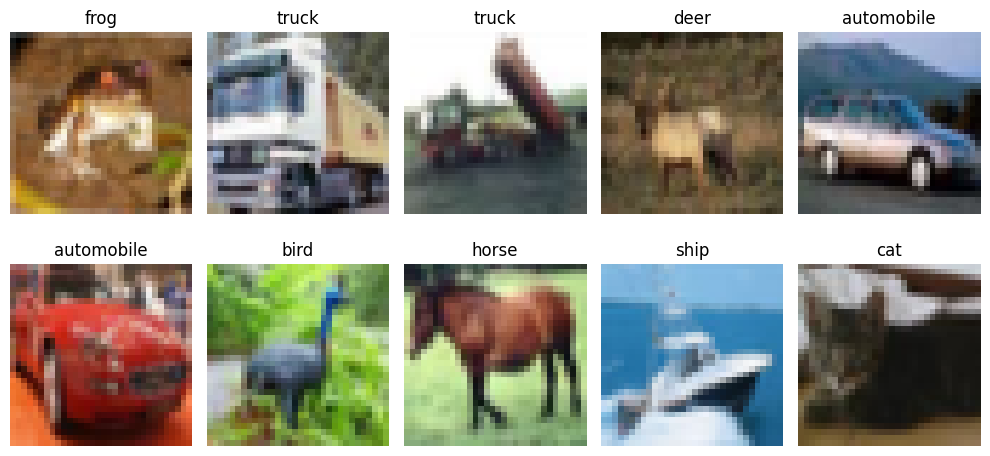

In [16]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [17]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.2345 - loss: 2.0559 - val_accuracy: 0.3110 - val_loss: 1.9140
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.2828 - loss: 1.9347 - val_accuracy: 0.3362 - val_loss: 1.8656
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.2998 - loss: 1.8914 - val_accuracy: 0.3354 - val_loss: 1.8717
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.3164 - loss: 1.8610 - val_accuracy: 0.3394 - val_loss: 1.8525
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.3253 - loss: 1.8395 - val_accuracy: 0.3522 - val_loss: 1.8245
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.3283 - loss: 1.8302 - val_accuracy: 0.3662 - val_loss: 1.8135
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.3320 - loss: 1.8188 - val_accuracy: 0.3716 - val_loss: 1.8025
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - accuracy: 0.3406 - loss: 1.8032 - 

In [20]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3891 - loss: 1.7150
ANN Test Accuracy: 0.38909998536109924


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [21]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.4638 - loss: 1.5027 - val_accuracy: 0.5518 - val_loss: 1.2735
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6043 - loss: 1.1314 - val_accuracy: 0.6366 - val_loss: 1.0667
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6665 - loss: 0.9543 - val_accuracy: 0.6444 - val_loss: 1.0324
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.7141 - loss: 0.8274 - val_accuracy: 0.6852 - val_loss: 0.9511
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.7461 - loss: 0.7295 - val_accuracy: 0.6300 - val_loss: 1.1043
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.7729 - loss: 0.6468 - val_accuracy: 0.6640 - val_loss: 0.9934
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.7920 - loss: 0.5871 - val_accuracy: 0.7248 - val_loss: 0.7925
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.8135 - loss: 0

In [22]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7211 - loss: 0.8470
CNN Test Accuracy: 0.7210999727249146


## 📈 Compare Learning Curves

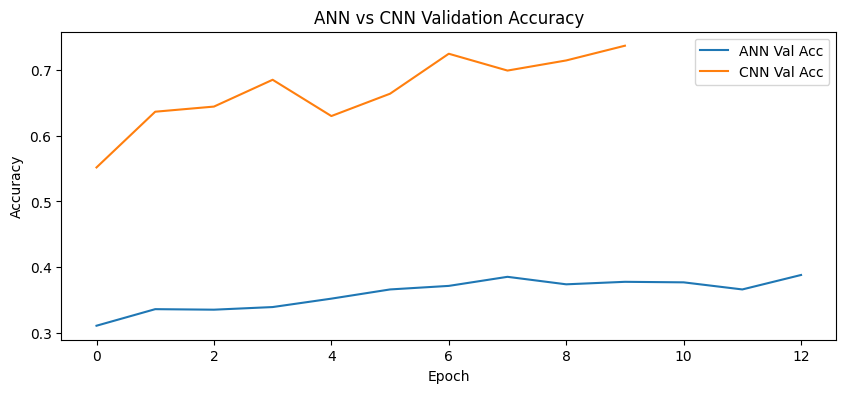

In [23]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [25]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[early_stop])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 84ms/step - accuracy: 0.3581 - loss: 1.7527 - val_accuracy: 0.4802 - val_loss: 1.4480
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.4568 - loss: 1.4995 - val_accuracy: 0.5274 - val_loss: 1.2890
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.4978 - loss: 1.4100 - val_accuracy: 0.5666 - val_loss: 1.2054


In [26]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4852 - loss: 1.4478
Augmented CNN Accuracy: 0.4851999878883362


# 📊 Final Comparison Table

In [27]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.3891
1,CNN,0.7211
2,CNN + Augmentation,0.4852


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**